In [1]:
from datasets.synth_deblur import SyntheticNonBlindDeblur, BlurConfig

In [3]:
blur_cfg = BlurConfig(sigma_list="4",
                      noise_prob=1.0,
                      noise_sigma_min=0.039,
                      noise_sigma_max=0.04)
full_ds = SyntheticNonBlindDeblur(
    "/inspire/hdd/global_user/gexinmu-253108100065/wl/unrolling_deblur/datasets/DIV2K_valid_256_random_5/*.png",
    blur_cfg,
    pad_border=32,
    T=5,
    sigma_schedule_name="uniform",
    sigma_schedule_kwargs={},
)

In [6]:
import math
from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import torch


def _tensor_to_numpy_img(x: torch.Tensor) -> np.ndarray:
    """
    Convert (C,H,W) tensor in [0,1] to (H,W,C) numpy.
    """
    return x.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()


def _calc_psnr(pred: torch.Tensor, target: torch.Tensor) -> float:
    """
    PSNR for tensors in [0,1], shape (C,H,W).
    """
    mse = torch.mean((pred - target) ** 2).item()
    if mse < 1e-12:
        return 100.0
    return 10.0 * math.log10(1.0 / mse)


def plot_dataset_sample(
    dataset,
    idx: int,
    save_path: Optional[str] = None,
    dpi: int = 150,
    figsize_per_panel: float = 3.0,
):
    """
    Plot one sample from SyntheticNonBlindDeblur.

    Layout:
        [ blur ] [ target_T ] [ target_{T-1} ] ... [ target_1 ] [ sharp ]

    where:
        - blur is the noisy blurred image
        - targets are shown from most blurry to clearest
        - sharp is the clean image

    Titles:
        - blur / each target: PSNR relative to sharp
        - sharp: title is 'sharp'

    Args:
        dataset: instance of SyntheticNonBlindDeblur
        idx: sample index
        save_path: if not None, save figure to this path
        dpi: figure dpi
        figsize_per_panel: width allocated for each image panel
    """
    sample = dataset[idx]

    blur = sample["blur"]          # (C,H,W)
    sharp = sample["sharp"]        # (C,H,W)
    targets = sample["targets"]    # list of T+1 tensors: [clean, ..., most_blurry]

    # middle panels: from blurry -> clear, excluding sharp itself
    target_seq = list(reversed(targets[1:]))

    panels = [blur] + target_seq + [sharp]
    titles = []

    # blur title
    blur_psnr = _calc_psnr(blur, sharp)
    titles.append(f"blur\nPSNR {blur_psnr:.2f}")

    # target titles
    for t in target_seq:
        p = _calc_psnr(t, sharp)
        titles.append(f"PSNR {p:.2f}")

    # sharp title
    titles.append("sharp")

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_panel * n, figsize_per_panel))

    if n == 1:
        axes = [axes]

    for ax, img, title in zip(axes, panels, titles):
        ax.imshow(_tensor_to_numpy_img(img))
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()
    plt.close(fig)

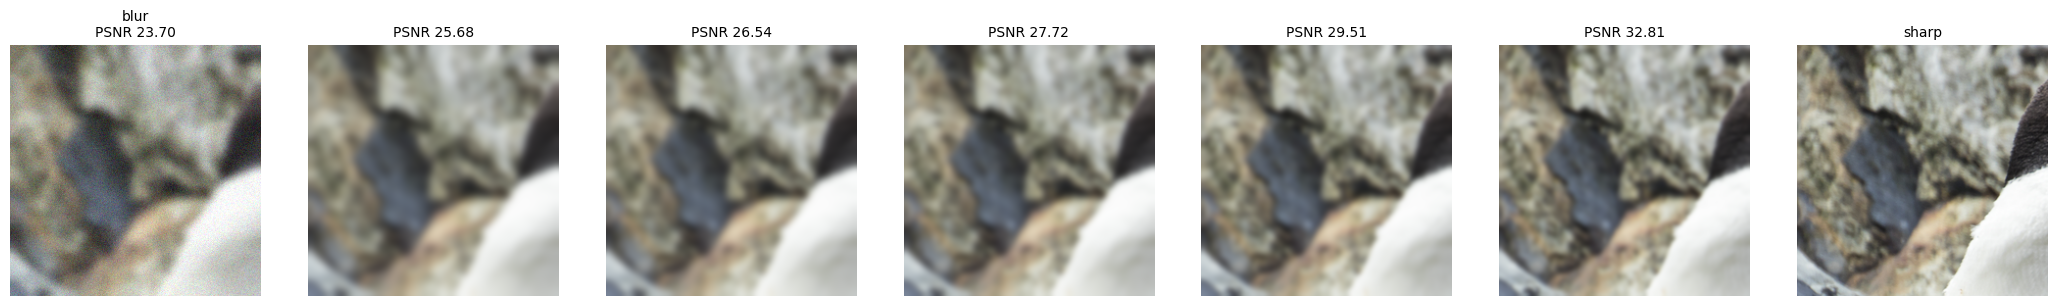

In [7]:
plot_dataset_sample(full_ds, idx=1, save_path="./sample1.png")